# Sprint 4 — Two-Phase Pipeline Final Analysis with Threshold Test

**Project:** CCTV Gun Detection  
**Sprint focus:** staged detection pipeline / two-phase formulation  
**Additional experiment:** `hold/no_hold` gate calibration from `0.85` to `0.50`, plus a redesigned permissive hold gate rerun

## Main question

Does the two-phase architecture improve over the single-stage YOLO26n baseline?

The threshold test confirms that **Stage 1 was the bottleneck**. Lowering the `hold/no_hold` threshold from `0.85` to `0.50` allowed more person crops to reach Stage 2 and improved recall/F1. The redesigned notebook flow also supports a permissive hold-gate rerun once the new artifacts are generated.

Therefore, the recommended model remains **single-stage YOLO26n**, while the two-phase pipeline is reported as a Sprint 4 ablation and failure-analysis experiment.

## 0. Setup

Run this notebook from the repository root:

```text
ComputerVision-CCTVgundetection/
```

In [2]:
from pathlib import Path
import os
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import display, Markdown

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (
            (candidate / "scripts/run_two_phase_inference.py").exists()
            and (candidate / "runs/two_phase").exists()
        ):
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)

FIG_DIR = PROJECT_ROOT / "docs" / "sprint4_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figure output:", FIG_DIR)

Project root: C:\Users\mathe\OneDrive\Documents\Documents\2026.1\cvproject\ComputerVision-CCTVgundetection
Figure output: C:\Users\mathe\OneDrive\Documents\Documents\2026.1\cvproject\ComputerVision-CCTVgundetection\docs\sprint4_figures


## 1. Artifact checklist

This notebook expects both:

- the original two-phase run using threshold `0.85`;
- the threshold-calibrated run using threshold `0.50`.

The threshold `0.50` outputs are expected to use the prefix `test_thr050`, while the redesigned permissive hold gate can use a prefix such as `test_holdgate`.

In [3]:
PATHS = {
    "comparison_085": PROJECT_ROOT / "runs/two_phase/evaluation/test_comparison.csv",
    "pipeline_085": PROJECT_ROOT / "runs/two_phase/predictions/test_pipeline_summary.csv",
    "image_summary_085": PROJECT_ROOT / "runs/two_phase/predictions/test_image_summary.csv",
    "predictions_085": PROJECT_ROOT / "runs/two_phase/predictions/test_predictions.csv",
    "two_phase_per_image_085": PROJECT_ROOT / "runs/two_phase/evaluation/test_two_phase_per_image.csv",

    "comparison_050": PROJECT_ROOT / "runs/two_phase/evaluation/test_thr050_comparison.csv",
    "pipeline_050": PROJECT_ROOT / "runs/two_phase/predictions/test_thr050_pipeline_summary.csv",
    "image_summary_050": PROJECT_ROOT / "runs/two_phase/predictions/test_thr050_image_summary.csv",
    "predictions_050": PROJECT_ROOT / "runs/two_phase/predictions/test_thr050_predictions.csv",
    "two_phase_per_image_050": PROJECT_ROOT / "runs/two_phase/evaluation/test_thr050_two_phase_per_image.csv",

    "comparison_holdgate": PROJECT_ROOT / "runs/two_phase/evaluation/test_holdgate_comparison.csv",
    "pipeline_holdgate": PROJECT_ROOT / "runs/two_phase/predictions/test_holdgate_pipeline_summary.csv",
    "image_summary_holdgate": PROJECT_ROOT / "runs/two_phase/predictions/test_holdgate_image_summary.csv",
    "predictions_holdgate": PROJECT_ROOT / "runs/two_phase/predictions/test_holdgate_predictions.csv",
    "two_phase_per_image_holdgate": PROJECT_ROOT / "runs/two_phase/evaluation/test_holdgate_two_phase_per_image.csv",

    "single_stage_predictions": PROJECT_ROOT / "runs/two_phase/evaluation/test_single_stage_predictions.csv",
    "single_stage_per_image": PROJECT_ROOT / "runs/two_phase/evaluation/test_single_stage_per_image.csv",

    "classifier_metrics": PROJECT_ROOT / "runs/two_phase/carry_classifier/metrics.csv",
    "dataset_summary_csv": PROJECT_ROOT / "data/interim/two_phase/metadata/two_phase_dataset_summary.csv",
    "dataset_summary_md": PROJECT_ROOT / "docs/sprint4_two_phase_dataset_summary.md",
    "test_manifest": PROJECT_ROOT / "data/splits/test_manifest.csv",
}

checklist = pd.DataFrame([
    {
        "artifact": key,
        "path": str(path.relative_to(PROJECT_ROOT)) if str(path).startswith(str(PROJECT_ROOT)) else str(path),
        "exists": path.exists(),
    }
    for key, path in PATHS.items()
])

display(checklist)

missing = checklist[~checklist["exists"]]
if len(missing) == 0:
    display(Markdown("✅ **All expected outputs were found.**"))
else:
    display(Markdown("⚠️ **Some outputs are missing. The notebook will still run where possible, but comparison cells expect the threshold-calibration artifacts and, optionally, the redesigned `test_holdgate` artifacts.**"))

,artifact,path,exists
0,comparison_085,runs\two_phase\evaluation\test_comparison.csv,True
1,pipeline_085,runs\two_phase\predictions\test_pipeline_summa...,True
2,image_summary_085,runs\two_phase\predictions\test_image_summary.csv,True
3,predictions_085,runs\two_phase\predictions\test_predictions.csv,True
4,two_phase_per_image_085,runs\two_phase\evaluation\test_two_phase_per_i...,True
5,comparison_050,runs\two_phase\evaluation\test_thr050_comparis...,True
6,pipeline_050,runs\two_phase\predictions\test_thr050_pipelin...,True
7,image_summary_050,runs\two_phase\predictions\test_thr050_image_s...,True
8,predictions_050,runs\two_phase\predictions\test_thr050_predict...,True
9,two_phase_per_image_050,runs\two_phase\evaluation\test_thr050_two_phas...,True


✅ **All expected outputs were found.**

## 2. Load results

In [4]:
def read_optional_csv(path_key):
    path = PATHS[path_key]
    return pd.read_csv(path) if path.exists() else None

comparison_085 = read_optional_csv("comparison_085")
pipeline_085 = read_optional_csv("pipeline_085")
image_summary_085 = read_optional_csv("image_summary_085")
predictions_085 = read_optional_csv("predictions_085")
two_phase_per_image_085 = read_optional_csv("two_phase_per_image_085")

comparison_050 = read_optional_csv("comparison_050")
pipeline_050 = read_optional_csv("pipeline_050")
image_summary_050 = read_optional_csv("image_summary_050")
predictions_050 = read_optional_csv("predictions_050")
two_phase_per_image_050 = read_optional_csv("two_phase_per_image_050")

comparison_holdgate = read_optional_csv("comparison_holdgate")
pipeline_holdgate = read_optional_csv("pipeline_holdgate")
image_summary_holdgate = read_optional_csv("image_summary_holdgate")
predictions_holdgate = read_optional_csv("predictions_holdgate")
two_phase_per_image_holdgate = read_optional_csv("two_phase_per_image_holdgate")

single_stage_predictions = read_optional_csv("single_stage_predictions")
single_stage_per_image = read_optional_csv("single_stage_per_image")

classifier_metrics = read_optional_csv("classifier_metrics")
dataset_summary = read_optional_csv("dataset_summary_csv")
test_manifest = read_optional_csv("test_manifest")

if comparison_085 is not None:
    display(Markdown("### Original comparison, threshold 0.85"))
    display(comparison_085)

if comparison_050 is not None:
    display(Markdown("### Calibrated comparison, threshold 0.50"))
    display(comparison_050)

if comparison_holdgate is not None:
    display(Markdown("### Redesigned hold-gate comparison"))
    display(comparison_holdgate)

### Original comparison, threshold 0.85

,pipeline,tp,fp,fn,precision,recall,f1,detections_per_image,stage0_miss_count,stage1_rejected,stage2_passed
0,single_stage,266,349,1247,0.432520,0.175810,0.250000,0.596508,NaN,NaN,NaN
1,two_phase,6,112,1507,0.050847,0.003966,0.007357,0.114452,42.0,2590.0,195.0
2,delta_two_phase_minus_single_stage,-260,-237,260,-0.381673,-0.171844,-0.242643,-0.482056,42.0,2590.0,195.0


### Calibrated comparison, threshold 0.50

,pipeline,tp,fp,fn,precision,recall,f1,detections_per_image,stage0_miss_count,stage1_rejected,stage2_passed
0,single_stage,266,349,1247,0.432520,0.175810,0.250000,0.596508,NaN,NaN,NaN
1,two_phase,24,333,1489,0.067227,0.015863,0.025668,0.346266,42.0,2051.0,734.0
2,delta_two_phase_minus_single_stage,-242,-16,242,-0.365293,-0.159947,-0.224332,-0.250242,42.0,2051.0,734.0


## 3. Main comparison table

This table combines:

- the **single-stage YOLO26n baseline**;
- the original **two-phase run with threshold 0.85**;
- the calibrated **two-phase run with threshold 0.50**.

,model,carry_threshold,tp,fp,fn,precision,recall,f1,detections_per_image,stage1_rejected,stage2_passed
0,Single-stage YOLO26n,NaN,266,349,1247,0.432520,0.175810,0.250000,0.596508,NaN,NaN
1,Two-phase,0.85,6,112,1507,0.050847,0.003966,0.007357,0.114452,2590.0,195.0
2,Two-phase,0.50,24,333,1489,0.067227,0.015863,0.025668,0.346266,2051.0,734.0


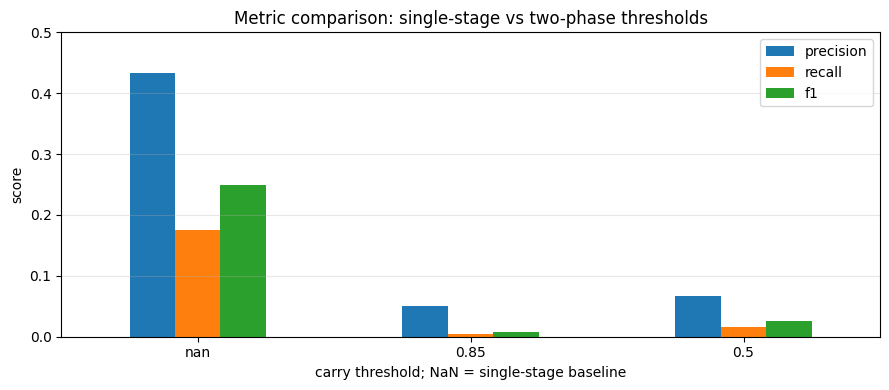

In [5]:
single = comparison_085[comparison_085["pipeline"] == "single_stage"].iloc[0].copy() if comparison_085 is not None else None
two_085 = comparison_085[comparison_085["pipeline"] == "two_phase"].iloc[0].copy() if comparison_085 is not None else None
two_050 = comparison_050[comparison_050["pipeline"] == "two_phase"].iloc[0].copy() if comparison_050 is not None else None
two_holdgate = comparison_holdgate[comparison_holdgate["pipeline"] == "two_phase"].iloc[0].copy() if comparison_holdgate is not None else None

summary_rows = []

def metric_row(name, row, threshold=None):
    return {
        "model": name,
        "carry_threshold": threshold,
        "tp": int(row["tp"]),
        "fp": int(row["fp"]),
        "fn": int(row["fn"]),
        "precision": float(row["precision"]),
        "recall": float(row["recall"]),
        "f1": float(row["f1"]),
        "detections_per_image": float(row["detections_per_image"]),
        "stage1_rejected": row.get("stage1_rejected", np.nan),
        "stage2_passed": row.get("stage2_passed", np.nan),
    }

if single is not None:
    summary_rows.append(metric_row("Single-stage YOLO26n", single, threshold=np.nan))
if two_085 is not None:
    summary_rows.append(metric_row("Two-phase", two_085, threshold=0.85))
if two_050 is not None:
    summary_rows.append(metric_row("Two-phase", two_050, threshold=0.50))
if two_holdgate is not None:
    summary_rows.append(metric_row("Two-phase hold gate", two_holdgate, threshold=two_holdgate.get("hold_threshold", np.nan)))

metrics_summary = pd.DataFrame(summary_rows)

display(metrics_summary)

ax = metrics_summary.set_index("carry_threshold")[["precision", "recall", "f1"]].plot(
    kind="bar",
    figsize=(9, 4),
)
ax.set_title("Metric comparison: single-stage vs two-phase thresholds")
ax.set_ylabel("score")
ax.set_xlabel("carry threshold; NaN = single-stage baseline")
ax.set_ylim(0, 0.5)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "sprint4_threshold_metric_comparison.png", dpi=200)
plt.show()

## 4. What changed after lowering the threshold?

Lowering the threshold from `0.85` to `0.50` directly targets the Stage 1 bottleneck.

Expected behavior:

- fewer people filtered out by Stage 1;
- more people sent to Stage 2;
- more final weapon detections;
- higher recall;
- possible increase in false positives.

,carry_threshold,images_processed,persons_detected,persons_filtered_out,persons_passed_stage2,final_weapon_detections,stage0_miss_images,stage1_filter_rate,stage2_pass_rate
0,0.85,1031,2785,2590,195,118,42,0.929982,0.070018
1,0.50,1031,2785,2051,734,357,42,0.736445,0.263555


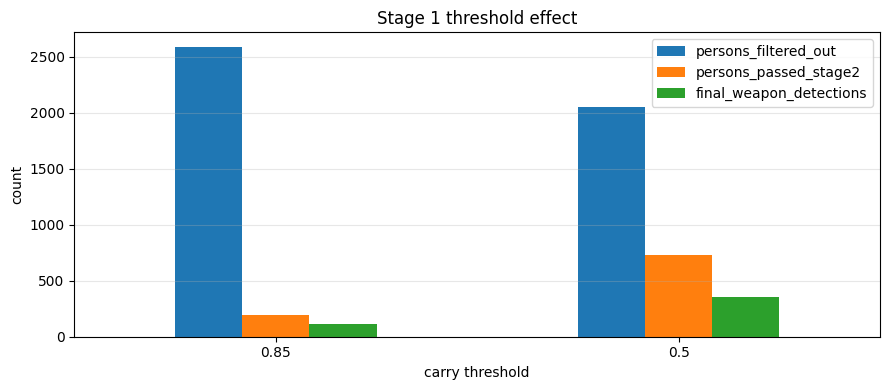


### Threshold test result

Moving from `0.85` to `0.50` changed the pipeline as follows:

| Quantity | Change |
|---|---:|
| Persons filtered out by Stage 1 | `-539` |
| Persons passed to Stage 2 | `+539` |
| Final weapon detections | `+239` |
| True positives | `+18` |
| False positives | `+221` |
| False negatives | `-18` |
| Recall | `+0.0119` |
| F1 | `+0.0183` |

**Interpretation:** lowering the threshold improved recall and F1, confirming that Stage 1 was too conservative. However, the two-phase pipeline still remains below the single-stage YOLO26n baseline.


In [6]:
pipe_085 = pipeline_085.iloc[0]
pipe_050 = pipeline_050.iloc[0]

funnel_compare = pd.DataFrame([
    {
        "carry_threshold": 0.85,
        "images_processed": int(pipe_085["images_processed"]),
        "persons_detected": int(pipe_085["persons_detected"]),
        "persons_filtered_out": int(pipe_085["persons_filtered_out"]),
        "persons_passed_stage2": int(pipe_085["persons_passed_stage2"]),
        "final_weapon_detections": int(pipe_085["final_weapon_detections"]),
        "stage0_miss_images": int(pipe_085["stage0_miss_images"]),
        "stage1_filter_rate": pipe_085["persons_filtered_out"] / max(pipe_085["persons_detected"], 1),
        "stage2_pass_rate": pipe_085["persons_passed_stage2"] / max(pipe_085["persons_detected"], 1),
    },
    {
        "carry_threshold": 0.50,
        "images_processed": int(pipe_050["images_processed"]),
        "persons_detected": int(pipe_050["persons_detected"]),
        "persons_filtered_out": int(pipe_050["persons_filtered_out"]),
        "persons_passed_stage2": int(pipe_050["persons_passed_stage2"]),
        "final_weapon_detections": int(pipe_050["final_weapon_detections"]),
        "stage0_miss_images": int(pipe_050["stage0_miss_images"]),
        "stage1_filter_rate": pipe_050["persons_filtered_out"] / max(pipe_050["persons_detected"], 1),
        "stage2_pass_rate": pipe_050["persons_passed_stage2"] / max(pipe_050["persons_detected"], 1),
    },
])

display(funnel_compare)

ax = funnel_compare.set_index("carry_threshold")[[
    "persons_filtered_out",
    "persons_passed_stage2",
    "final_weapon_detections",
]].plot(kind="bar", figsize=(9, 4))
ax.set_title("Stage 1 threshold effect")
ax.set_ylabel("count")
ax.set_xlabel("carry threshold")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "sprint4_threshold_funnel_comparison.png", dpi=200)
plt.show()

delta_filtered = int(pipe_050["persons_filtered_out"] - pipe_085["persons_filtered_out"])
delta_passed = int(pipe_050["persons_passed_stage2"] - pipe_085["persons_passed_stage2"])
delta_detections = int(pipe_050["final_weapon_detections"] - pipe_085["final_weapon_detections"])

delta_tp = int(two_050["tp"] - two_085["tp"])
delta_fp = int(two_050["fp"] - two_085["fp"])
delta_fn = int(two_050["fn"] - two_085["fn"])
delta_recall = float(two_050["recall"] - two_085["recall"])
delta_f1 = float(two_050["f1"] - two_085["f1"])

display(Markdown(f'''
### Threshold test result

Moving from `0.85` to `0.50` changed the pipeline as follows:

| Quantity | Change |
|---|---:|
| Persons filtered out by Stage 1 | `{delta_filtered:+d}` |
| Persons passed to Stage 2 | `{delta_passed:+d}` |
| Final weapon detections | `{delta_detections:+d}` |
| True positives | `{delta_tp:+d}` |
| False positives | `{delta_fp:+d}` |
| False negatives | `{delta_fn:+d}` |
| Recall | `{delta_recall:+.4f}` |
| F1 | `{delta_f1:+.4f}` |

**Interpretation:** lowering the threshold improved recall and F1, confirming that Stage 1 was too conservative. However, the two-phase pipeline still remains below the single-stage YOLO26n baseline.
'''))

## 5. Dataset and classifier context

,split,carry_crops,no_carry_crops,total_crops,carry_ratio
0,train,885,3025,3910,0.226343
1,val,89,407,496,0.179435
2,test,1466,1093,2559,0.572880


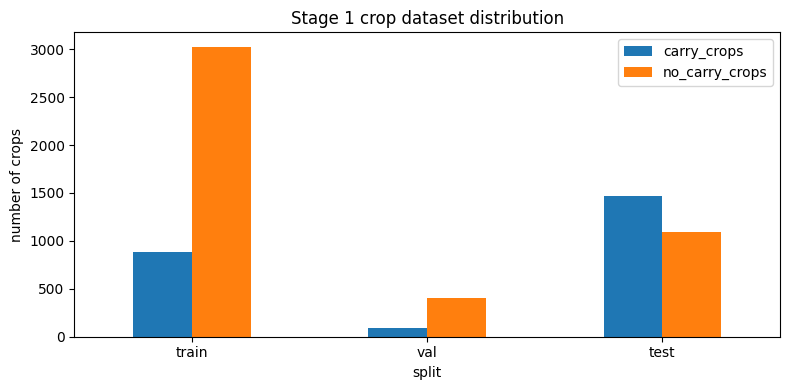

### Carry/no-carry classifier metrics

,kind,epoch,split,loss,train_loss,threshold,precision,recall,f1,accuracy,tp,fp,fn,tn
0,epoch,1,val,0.714172,0.935448,0.45,0.356164,0.876404,0.506494,0.693548,78,141,11,266
1,epoch,2,val,0.909821,0.769819,0.65,0.344681,0.910112,0.500000,0.673387,81,154,8,253
2,epoch,3,val,0.913366,0.709574,0.85,0.414062,0.595506,0.488479,0.776210,53,75,36,332
3,epoch,4,val,0.723694,0.669609,0.70,0.403974,0.685393,0.508333,0.762097,61,90,28,317
4,epoch,5,val,0.755148,0.644871,0.65,0.393750,0.707865,0.506024,0.752016,63,97,26,310
5,epoch,6,val,0.724511,0.612967,0.85,0.555556,0.561798,0.558659,0.840726,50,40,39,367
6,epoch,7,val,0.839257,0.574092,0.90,0.542169,0.505618,0.523256,0.834677,45,38,44,369
7,epoch,8,val,0.681574,0.558468,0.45,0.433962,0.775281,0.556452,0.778226,69,90,20,317
8,epoch,9,val,0.735336,0.535382,0.50,0.491803,0.674157,0.568720,0.816532,60,62,29,345
9,epoch,10,val,0.737003,0.504974,0.95,0.736842,0.471910,0.575342,0.875000,42,15,47,392



        The trained classifier selected threshold `0.85` based on validation behavior. This threshold produced high precision but low recall on test crops, which explains why the full pipeline initially filtered out too many candidates.
        

In [7]:
if dataset_summary is not None:
    ds = dataset_summary.copy()
    if {"split", "hold_crops", "no_hold_crops"}.issubset(ds.columns):
        ds["total_crops"] = ds["hold_crops"] + ds["no_hold_crops"]
        ds["hold_ratio"] = ds["hold_crops"] / ds["total_crops"].replace(0, np.nan)
        display(ds[["split", "hold_crops", "no_hold_crops", "total_crops", "hold_ratio"]])

        ax = ds.set_index("split")[["hold_crops", "no_hold_crops"]].plot(kind="bar", figsize=(8, 4))
        ax.set_title("Stage 1 crop dataset distribution")
        ax.set_ylabel("number of crops")
        ax.set_xlabel("split")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig(FIG_DIR / "sprint4_crop_distribution.png", dpi=200)
        plt.show()
elif PATHS["dataset_summary_md"].exists():
    display(Markdown(PATHS["dataset_summary_md"].read_text(encoding="utf-8")))

if classifier_metrics is not None:
    display(Markdown("### Hold/no-hold classifier metrics"))
    display(classifier_metrics)

    final_classifier = classifier_metrics[classifier_metrics["kind"] == "final"].copy()
    if len(final_classifier):
        row = final_classifier.iloc[0]
        display(Markdown(f'''
        The trained classifier selected threshold `{row.get("stage1_gate_threshold", row.get("threshold", 0.5)):.2f}` for the real hold gate. This threshold is intentionally permissive so more person crops reach Phase 2 before the final weapon decision.
        '''))

## 6. Qualitative comparison with bounding boxes

The following visual analysis compares four views:

1. **Ground truth** — manually annotated weapon boxes;
2. **Single-stage YOLO26n** — baseline predictions;
3. **Two-phase threshold 0.85** — original two-phase predictions;
4. **Two-phase threshold 0.50** — calibrated two-phase predictions.

Color legend:

- **green** = ground truth;
- **orange** = single-stage prediction;
- **cyan** = two-phase prediction at threshold `0.85`;
- **magenta** = two-phase prediction at threshold `0.50`.

In [8]:
def clean_path_str(value) -> str:
    return str(value).replace("\\", "/")

def to_project_path(value) -> Path:
    p = Path(clean_path_str(value))
    if p.is_absolute():
        return p
    return PROJECT_ROOT / p

def add_prefix_except_key(df: pd.DataFrame, prefix: str, key: str = "image_path") -> pd.DataFrame:
    out = df.copy()
    out[key] = out[key].astype(str).map(clean_path_str)
    rename = {c: f"{prefix}_{c}" for c in out.columns if c != key}
    return out.rename(columns=rename)

WEAPON_CLASSES = {
    "handgun",
    "short_rifle",
    "short-rifle",
    "rifle",
    "gun",
    "pistol",
    "revolver",
    "firearm",
    "weapon",
}

def normalize_class_name(name: str) -> str:
    return str(name).strip().lower().replace(" ", "_")

def infer_annotation_path(image_path) -> Path:
    p = clean_path_str(image_path)
    p = p.replace("/images/", "/annotations/")
    for suffix in [".jpg", ".jpeg", ".png"]:
        if p.lower().endswith(suffix):
            p = p[: -len(suffix)] + ".xml"
            break
    return to_project_path(p)

def parse_voc_weapon_boxes(annotation_path) -> list[dict]:
    path = to_project_path(annotation_path)
    if not path.exists():
        return []

    try:
        root = ET.parse(path).getroot()
    except Exception:
        return []

    boxes = []
    for obj in root.findall("object"):
        cls = normalize_class_name(obj.findtext("name", ""))
        if cls not in WEAPON_CLASSES:
            continue

        bnd = obj.find("bndbox")
        if bnd is None:
            continue

        try:
            boxes.append({
                "label": "GT",
                "confidence": 1.0,
                "xmin": float(bnd.findtext("xmin")),
                "ymin": float(bnd.findtext("ymin")),
                "xmax": float(bnd.findtext("xmax")),
                "ymax": float(bnd.findtext("ymax")),
            })
        except Exception:
            pass

    return boxes

def prediction_boxes(pred_df: pd.DataFrame, image_path, label: str) -> list[dict]:
    image_key = clean_path_str(image_path)
    df = pred_df.copy()
    df["image_path"] = df["image_path"].astype(str).map(clean_path_str)
    rows = df[df["image_path"] == image_key]

    boxes = []
    for _, r in rows.iterrows():
        boxes.append({
            "label": label,
            "confidence": float(r.get("weapon_confidence", 1.0)),
            "xmin": float(r["xmin"]),
            "ymin": float(r["ymin"]),
            "xmax": float(r["xmax"]),
            "ymax": float(r["ymax"]),
        })
    return boxes

COLOR_MAP = {
    "GT": "lime",
    "SS": "orange",
    "2P85": "cyan",
    "2P50": "magenta",
}

READABLE_LABELS = {
    "GT": "GT",
    "SS": "Single",
    "2P85": "2P 0.85",
    "2P50": "2P 0.50",
}

def draw_label(draw, xy, text, color):
    x, y = xy
    margin = 3
    bbox = draw.textbbox((x, y), text)
    draw.rectangle(
        [bbox[0] - margin, bbox[1] - margin, bbox[2] + margin, bbox[3] + margin],
        fill="black",
    )
    draw.text((x, y), text, fill=color)

def draw_boxes_on_image(image_path, boxes):
    image_file = to_project_path(image_path)
    img = Image.open(image_file).convert("RGB")
    draw = ImageDraw.Draw(img)

    for box in boxes:
        label = box["label"]
        color = COLOR_MAP.get(label, "yellow")
        xy = [box["xmin"], box["ymin"], box["xmax"], box["ymax"]]
        draw.rectangle(xy, outline=color, width=5)

        text = READABLE_LABELS.get(label, label)
        if label != "GT":
            text += f" {box['confidence']:.2f}"

        y = max(0, box["ymin"] - 18)
        draw_label(draw, (box["xmin"], y), text, color)

    return img

def build_per_image_table():
    per_image = (
        add_prefix_except_key(single_stage_per_image, "ss")
        .merge(add_prefix_except_key(two_phase_per_image_085, "tp085"), on="image_path", how="outer")
        .merge(add_prefix_except_key(two_phase_per_image_050, "tp050"), on="image_path", how="outer")
        .merge(add_prefix_except_key(image_summary_085, "stage085"), on="image_path", how="left")
        .merge(add_prefix_except_key(image_summary_050, "stage050"), on="image_path", how="left")
    )

    # Convert only columns that are actually numeric-like.
    # Some newer pandas versions do not accept errors="ignore" in pd.to_numeric,
    # so we use errors="coerce" and only keep the conversion when it produced at least
    # one valid numeric value.
    protected_suffixes = ("_image_stem", "_split", "_annotation_path")
    protected_cols = {"image_path", "annotation_path"}

    for col in per_image.columns:
        if col in protected_cols or col.endswith(protected_suffixes):
            continue

        converted = pd.to_numeric(per_image[col], errors="coerce")
        if converted.notna().any():
            per_image[col] = converted

    numeric_cols = [
        c for c in per_image.columns
        if c not in protected_cols and pd.api.types.is_numeric_dtype(per_image[c])
    ]
    per_image[numeric_cols] = per_image[numeric_cols].fillna(0)

    if test_manifest is not None:
        manifest_small = test_manifest.copy()
        manifest_small["image_path"] = manifest_small["image_path"].astype(str).map(clean_path_str)
        keep_cols = [c for c in ["image_path", "annotation_path"] if c in manifest_small.columns]
        per_image = per_image.merge(manifest_small[keep_cols], on="image_path", how="left")
    else:
        per_image["annotation_path"] = np.nan

    per_image["has_gt"] = per_image["ss_ground_truth_boxes"].fillna(0) > 0
    return per_image

per_image = build_per_image_table()

cases = {
    "A_single_stage_hits_two_phase050_misses": per_image[
        (per_image["has_gt"])
        & (per_image["ss_tp"] > 0)
        & (per_image["tp050_tp"] == 0)
    ].copy(),

    "B_threshold050_improves_over085": per_image[
        (per_image["has_gt"])
        & (per_image["tp050_tp"] > per_image["tp085_tp"])
    ].copy(),

    "C_two_phase050_success": per_image[
        (per_image["tp050_tp"] > 0)
    ].copy(),

    "D_stage1_still_rejects_all_at050": per_image[
        (per_image["has_gt"])
        & (per_image["stage050_persons_detected"] > 0)
        & (per_image["stage050_persons_passed_stage2"] == 0)
    ].copy(),
}

display(pd.DataFrame([{"case": k, "num_images": len(v)} for k, v in cases.items()]))

,case,num_images
0,A_single_stage_hits_two_phase050_misses,221
1,B_threshold050_improves_over085,18
2,C_two_phase050_success,24
3,D_stage1_still_rejects_all_at050,335


## 7. Threshold test effect

The most useful case is **B_threshold050_improves_over085**, because it shows images where lowering the threshold recovered detections that the original two-phase configuration missed.

In [9]:
def get_annotation_for_row(row) -> Path:
    ann = row.get("annotation_path", np.nan)
    if isinstance(ann, str) and ann and ann != "nan":
        return to_project_path(ann)
    return infer_annotation_path(row["image_path"])

def explain_row(row) -> str:
    gt = int(row.get("ss_ground_truth_boxes", 0))

    ss_tp = int(row.get("ss_tp", 0))
    ss_fp = int(row.get("ss_fp", 0))
    ss_fn = int(row.get("ss_fn", 0))

    tp085_tp = int(row.get("tp085_tp", 0))
    tp085_fp = int(row.get("tp085_fp", 0))
    tp085_fn = int(row.get("tp085_fn", 0))

    tp050_tp = int(row.get("tp050_tp", 0))
    tp050_fp = int(row.get("tp050_fp", 0))
    tp050_fn = int(row.get("tp050_fn", 0))

    passed085 = int(row.get("stage085_persons_passed_stage2", 0))
    detected085 = int(row.get("stage085_persons_detected", 0))
    passed050 = int(row.get("stage050_persons_passed_stage2", 0))
    detected050 = int(row.get("stage050_persons_detected", 0))

    if tp050_tp > tp085_tp:
        diagnosis = "Lowering the threshold recovered at least one true positive that was missed by the original two-phase run."
    elif detected050 > 0 and passed050 == 0:
        diagnosis = "Even at threshold 0.50, Stage 1 still rejected all detected people in this image."
    elif ss_tp > tp050_tp:
        diagnosis = "Single-stage still detects more true positives than the calibrated two-phase pipeline."
    elif tp050_tp > 0:
        diagnosis = "The calibrated two-phase pipeline detects at least one weapon in this image."
    else:
        diagnosis = "Both models struggle in this image, likely due to small object size, occlusion, blur, or insufficient context."

    return (
        f"Image summary\\n"
        f"• Ground-truth weapons: {gt}\\n"
        f"• Single-stage: {ss_tp} TP, {ss_fp} FP, {ss_fn} FN\\n"
        f"• Two-phase 0.85: {tp085_tp} TP, {tp085_fp} FP, {tp085_fn} FN; Stage 1 passed {passed085}/{detected085}\\n"
        f"• Two-phase 0.50: {tp050_tp} TP, {tp050_fp} FP, {tp050_fn} FN; Stage 1 passed {passed050}/{detected050}\\n"
        f"• Diagnosis: {diagnosis}"
    )

def show_case_examples_4panel(case_name: str, n: int = 3, seed: int = 42, save: bool = True):
    if case_name not in cases:
        raise ValueError(f"Unknown case: {case_name}. Available: {list(cases)}")

    df = cases[case_name]
    if len(df) == 0:
        display(Markdown(f"No examples found for `{case_name}`."))
        return

    sample = df.sample(min(n, len(df)), random_state=seed)

    for idx, (_, row) in enumerate(sample.iterrows(), start=1):
        image_path = row["image_path"]
        image_file = to_project_path(image_path)

        if not image_file.exists():
            display(Markdown(f"⚠️ Image not found: `{image_file}`"))
            continue

        annotation_path = get_annotation_for_row(row)
        gt_boxes = parse_voc_weapon_boxes(annotation_path)

        ss_boxes = prediction_boxes(single_stage_predictions, image_path, "SS")
        tp085_boxes = prediction_boxes(predictions_085, image_path, "2P85")
        tp050_boxes = prediction_boxes(predictions_050, image_path, "2P50")

        panels = [
            ("Ground truth", gt_boxes),
            ("Single-stage YOLO26n", gt_boxes + ss_boxes),
            ("Two-phase, threshold 0.85", gt_boxes + tp085_boxes),
            ("Two-phase, threshold 0.50", gt_boxes + tp050_boxes),
        ]

        fig, axes = plt.subplots(1, 4, figsize=(22, 6))

        for ax, (title, boxes) in zip(axes, panels):
            img = draw_boxes_on_image(image_path, boxes)
            ax.imshow(img)
            ax.set_title(title, fontsize=11)
            ax.axis("off")

        fig.suptitle(
            f"Case: {case_name} | Image: {Path(image_path).name}",
            fontsize=13,
            fontweight="bold",
            y=0.98,
        )

        fig.text(
            0.01,
            0.91,
            explain_row(row),
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(facecolor="white", edgecolor="black", alpha=0.95, boxstyle="round,pad=0.4"),
        )

        fig.text(
            0.01,
            0.03,
            "Legend: green = ground truth | orange = single-stage | cyan = two-phase 0.85 | magenta = two-phase 0.50",
            ha="left",
            va="bottom",
            fontsize=10,
            bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9, boxstyle="round,pad=0.3"),
        )

        plt.tight_layout(rect=[0, 0.07, 1, 0.78])

        if save:
            out_path = FIG_DIR / f"{case_name}_{idx}_threshold_comparison.png"
            plt.savefig(out_path, dpi=180, bbox_inches="tight")
            print("Saved:", out_path.relative_to(PROJECT_ROOT))

        plt.show()

Saved: docs\sprint4_figures\B_threshold050_improves_over085_1_threshold_comparison.png


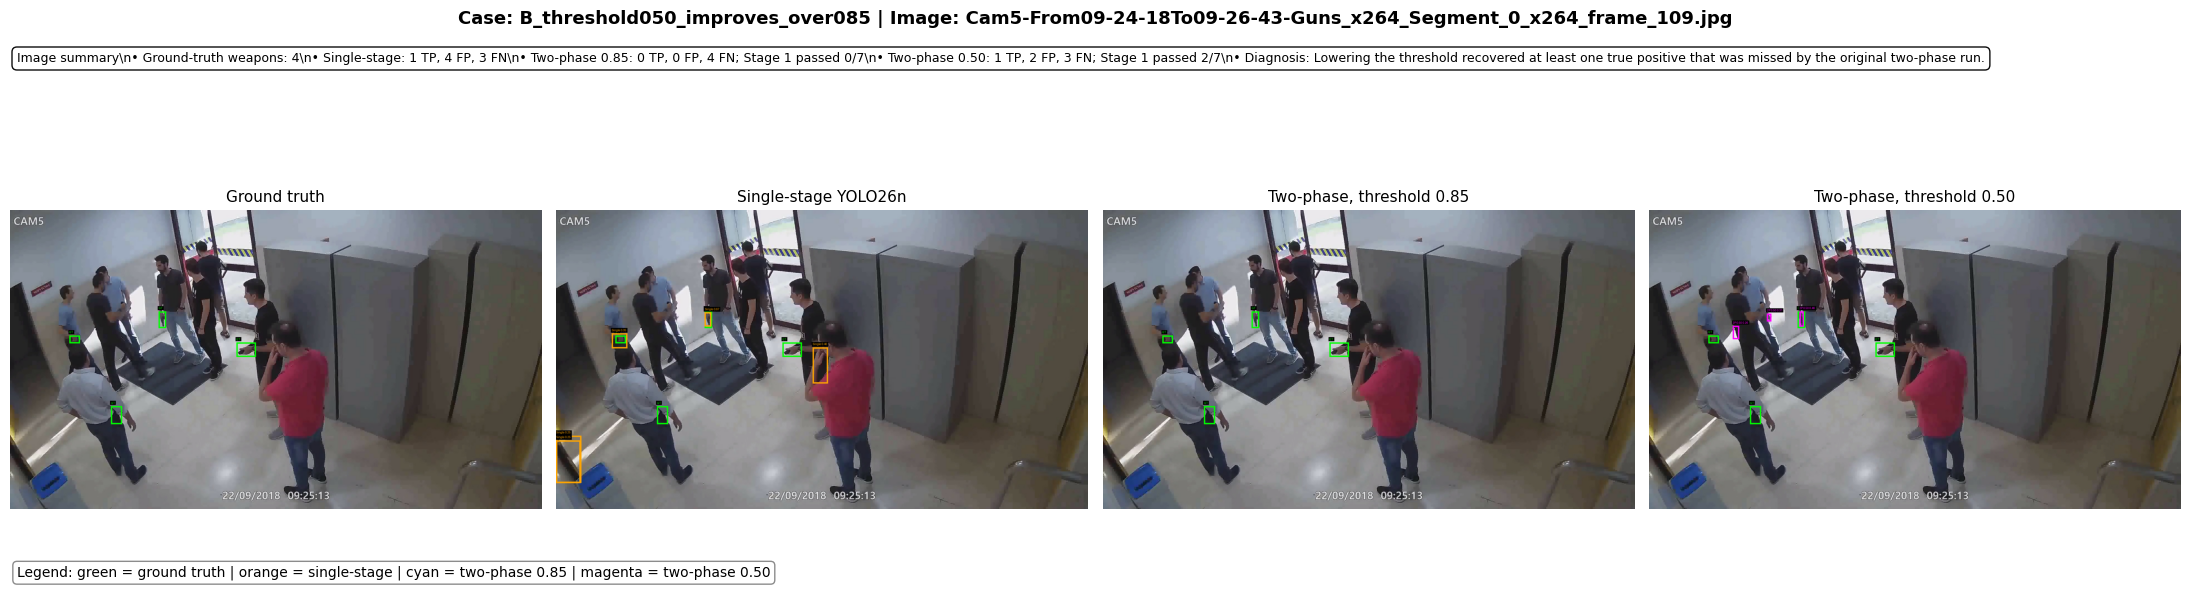

Saved: docs\sprint4_figures\B_threshold050_improves_over085_2_threshold_comparison.png


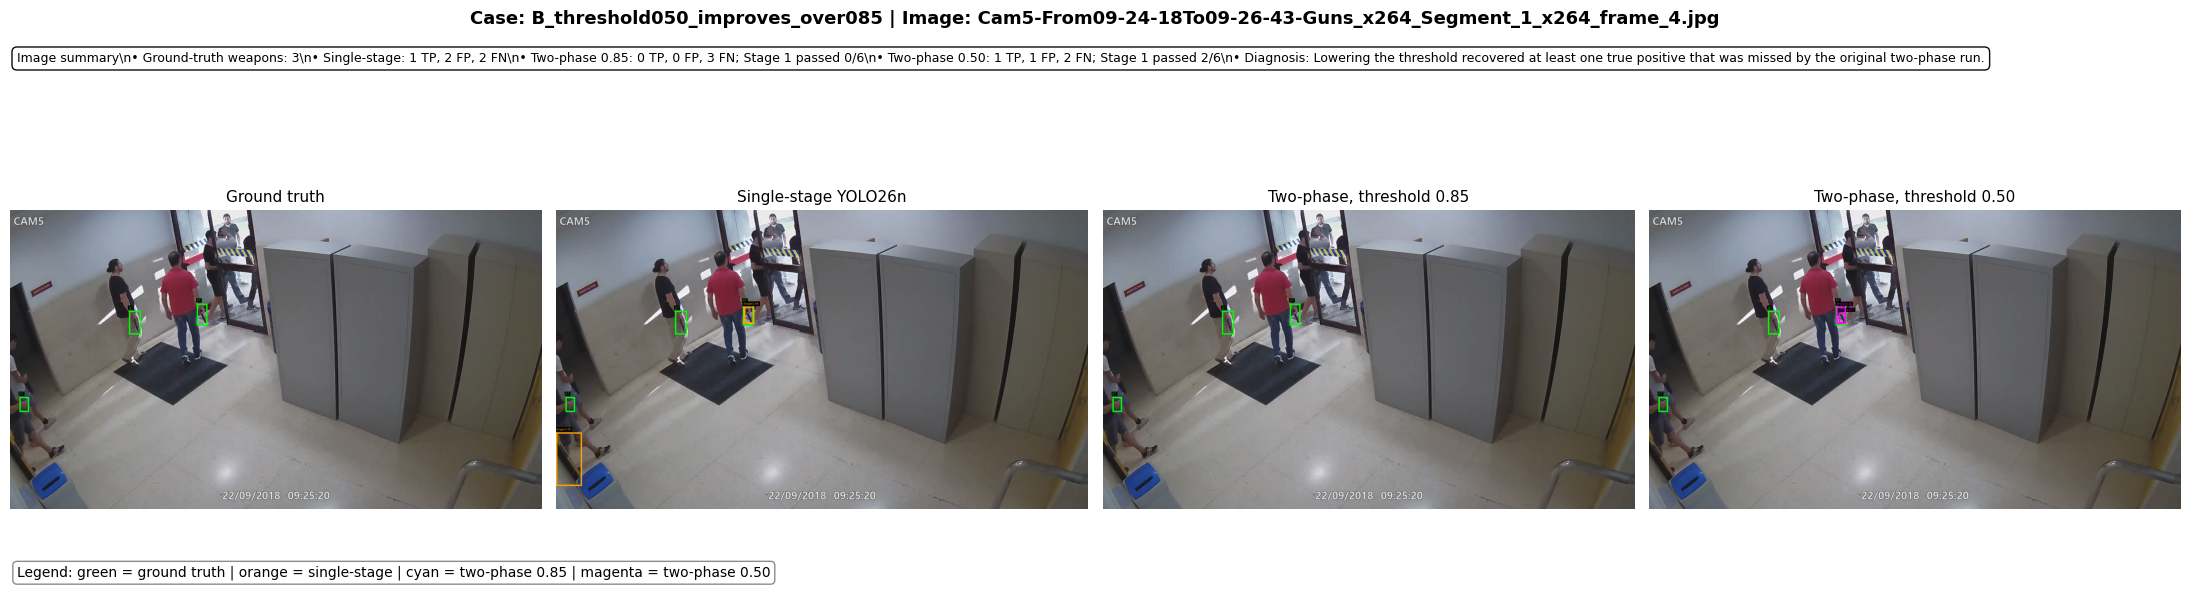

Saved: docs\sprint4_figures\B_threshold050_improves_over085_3_threshold_comparison.png


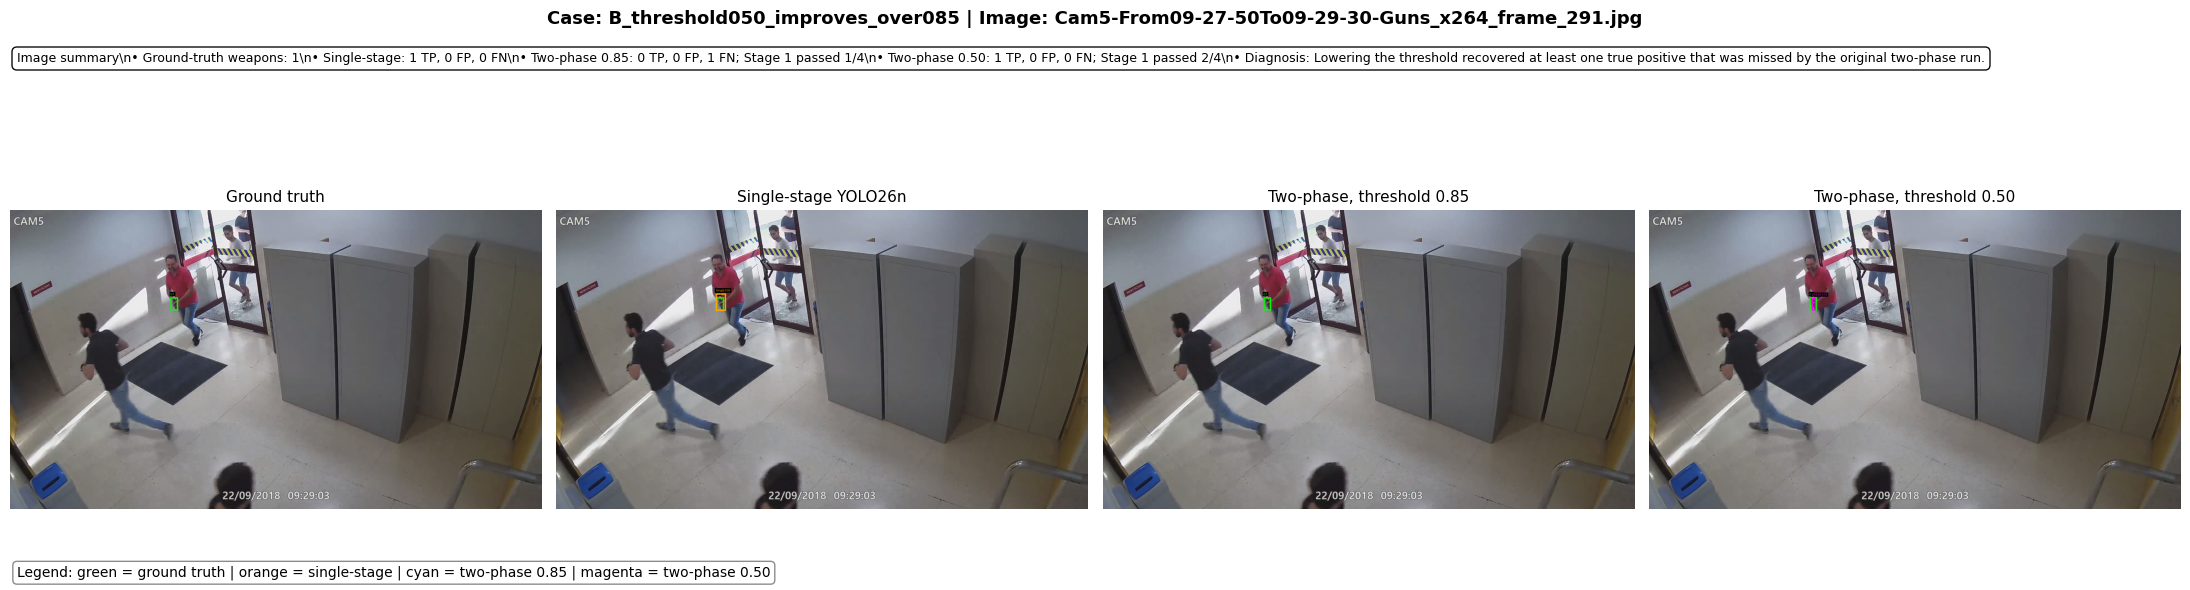

In [10]:
show_case_examples_4panel("B_threshold050_improves_over085", n=3)

### Remaining failures after threshold calibration

These examples show that threshold `0.50` improves recall but does not solve the full problem.

Saved: docs\sprint4_figures\A_single_stage_hits_two_phase050_misses_1_threshold_comparison.png


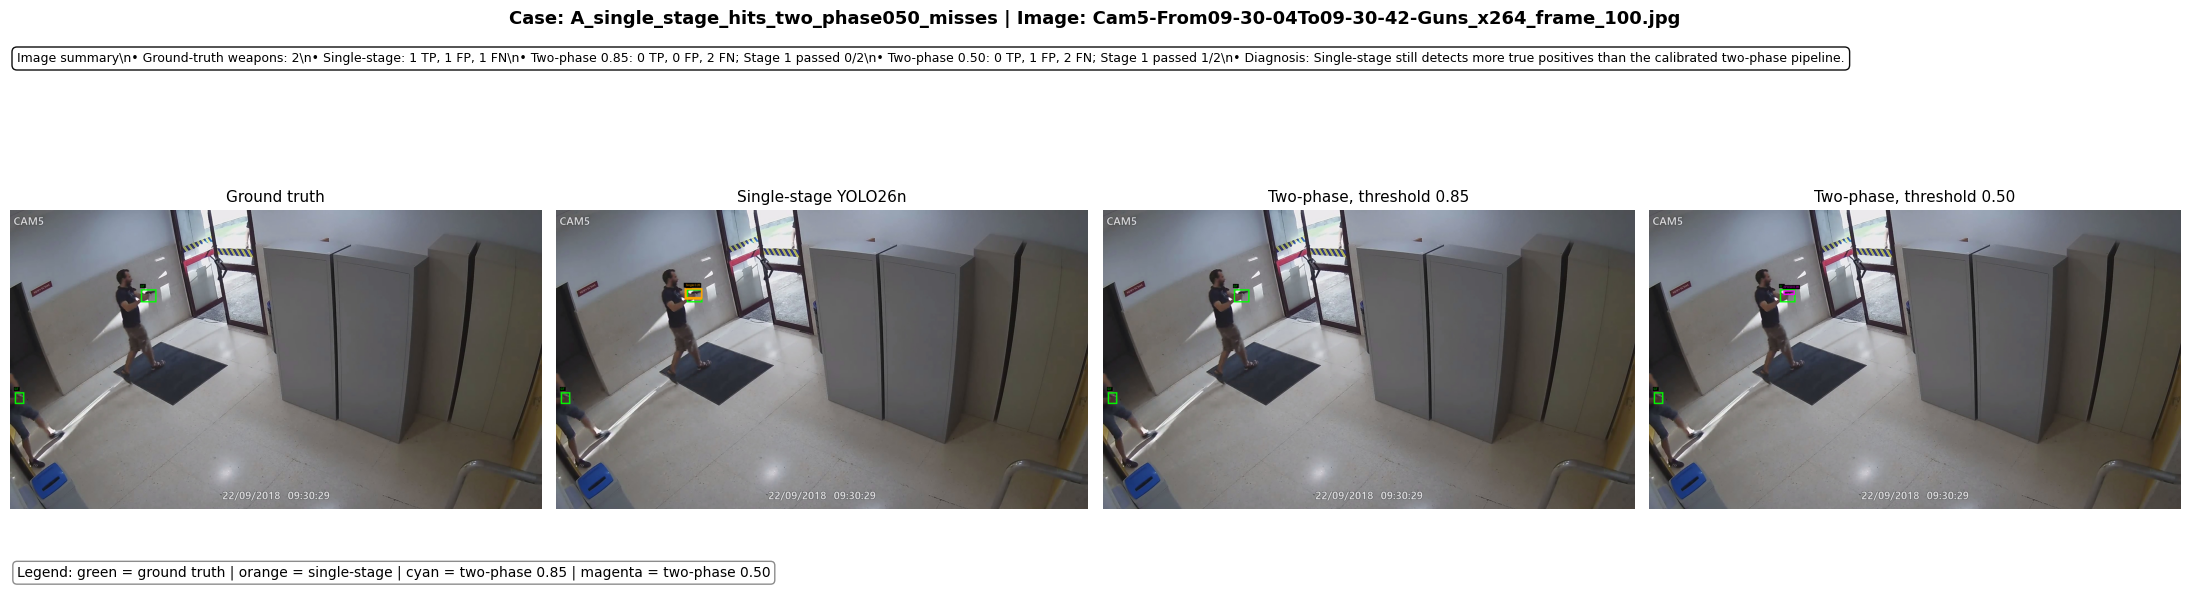

Saved: docs\sprint4_figures\A_single_stage_hits_two_phase050_misses_2_threshold_comparison.png


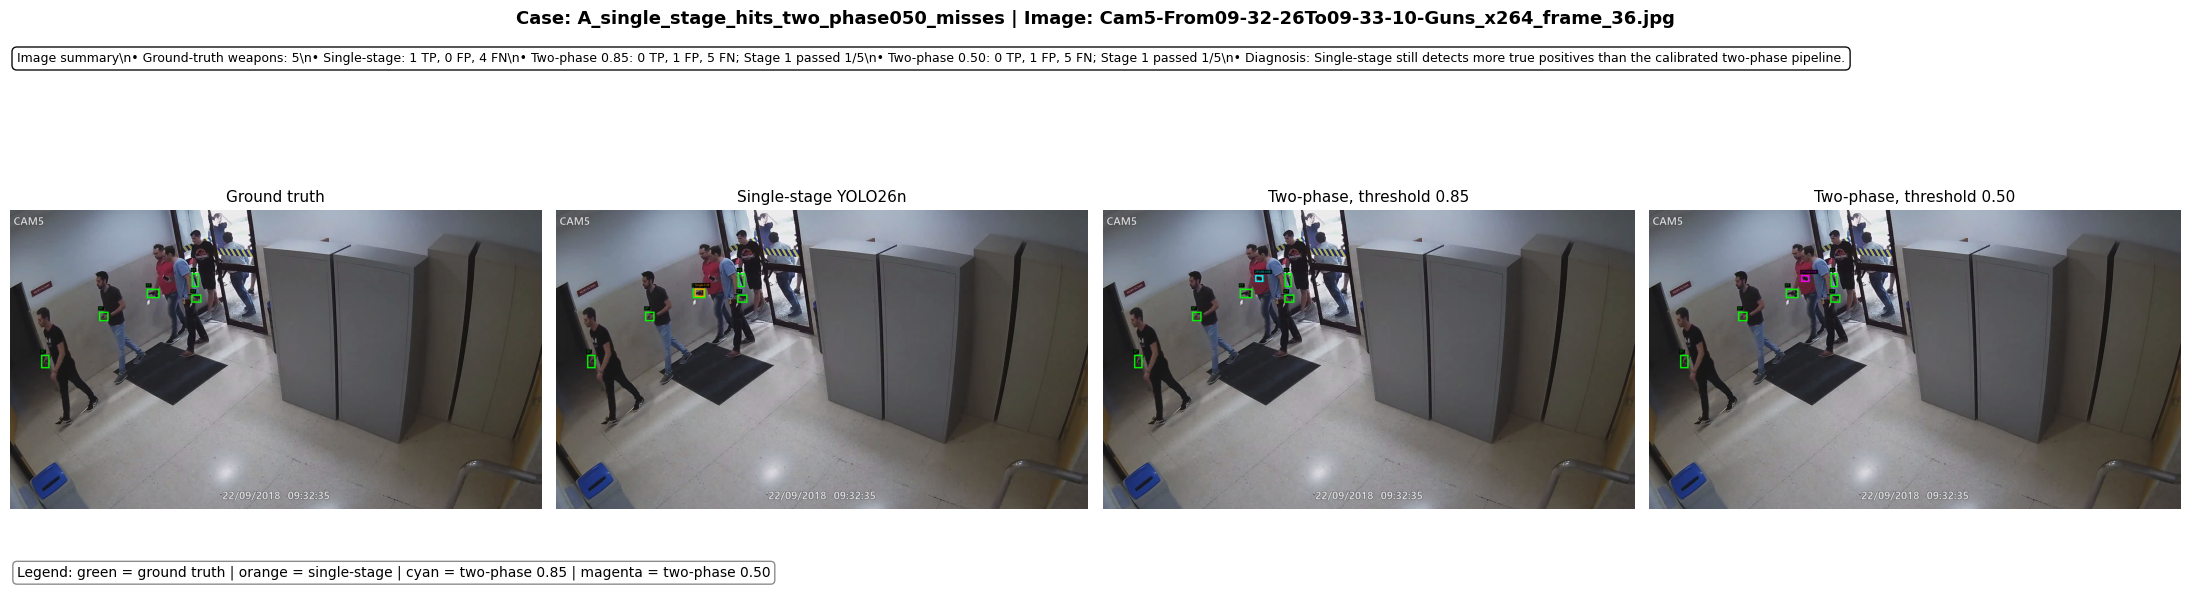

Saved: docs\sprint4_figures\A_single_stage_hits_two_phase050_misses_3_threshold_comparison.png


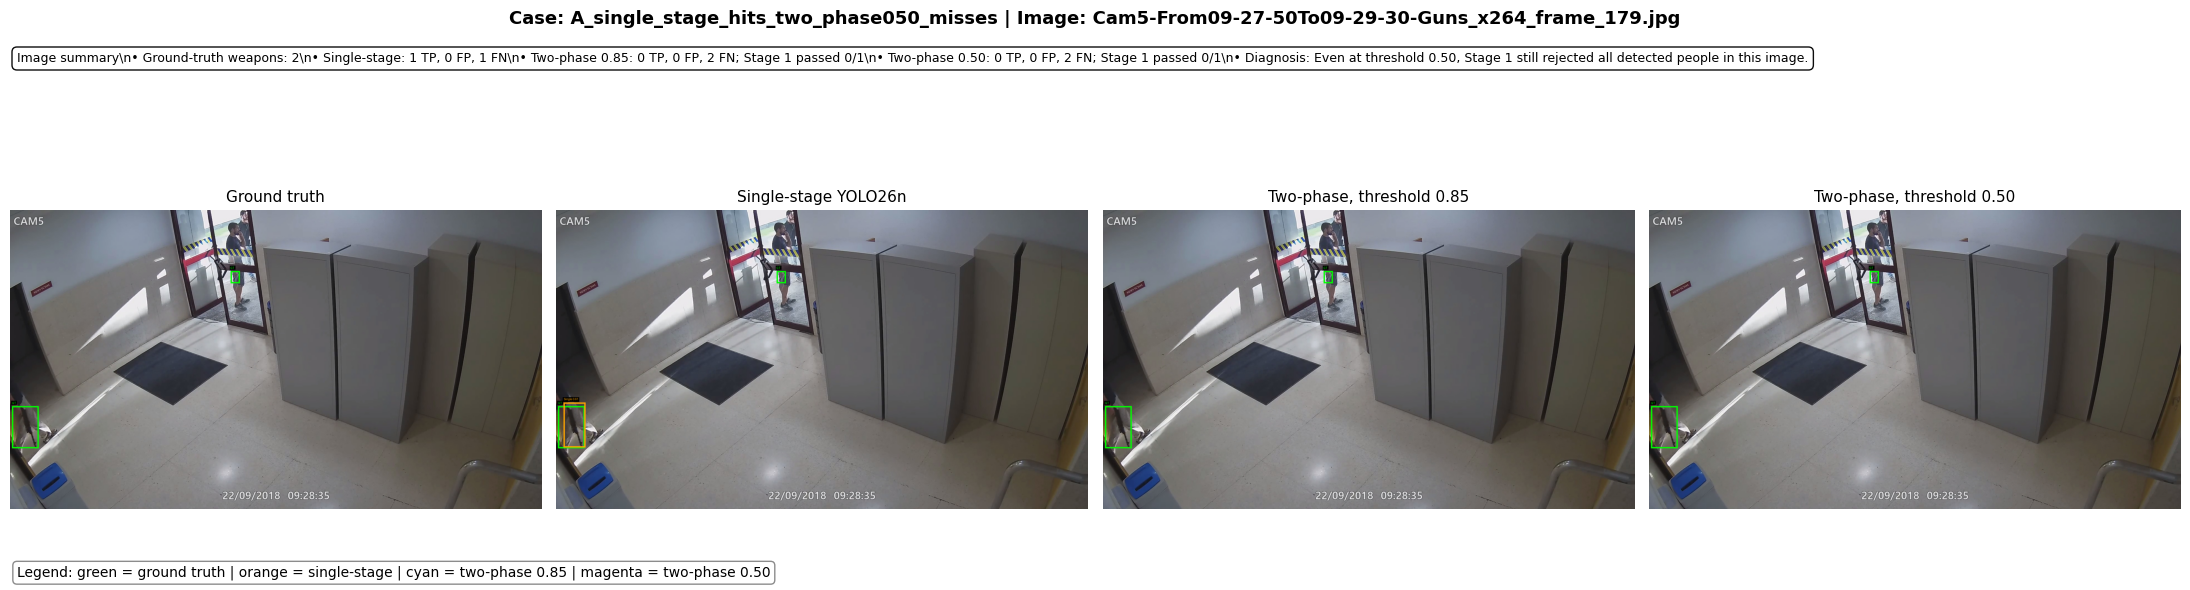

In [11]:
show_case_examples_4panel("A_single_stage_hits_two_phase050_misses", n=3)

### Two-phase success cases at threshold 0.50

Saved: docs\sprint4_figures\C_two_phase050_success_1_threshold_comparison.png


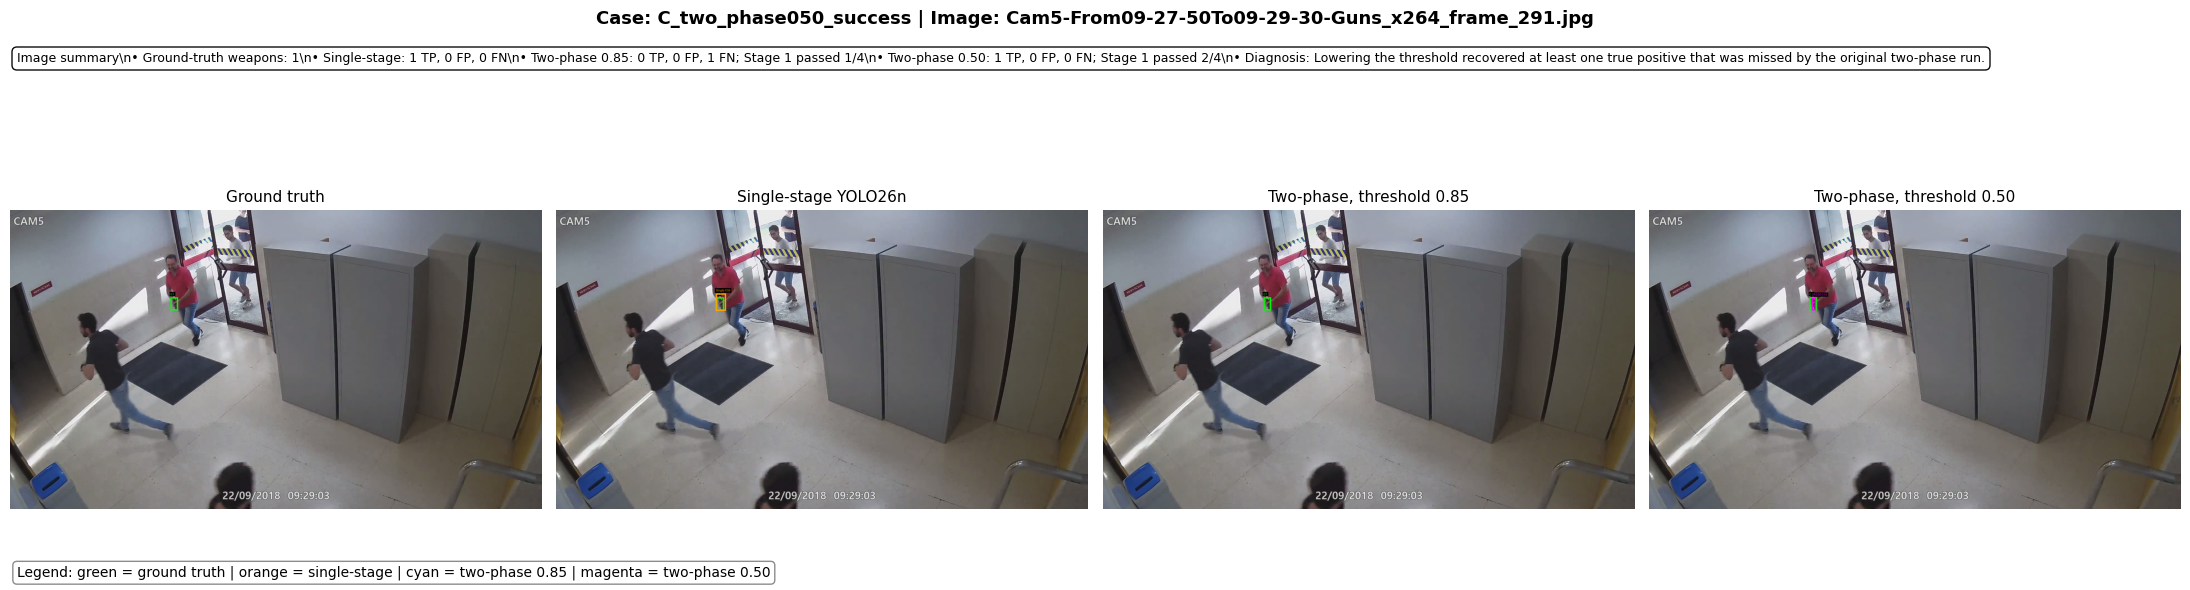

Saved: docs\sprint4_figures\C_two_phase050_success_2_threshold_comparison.png


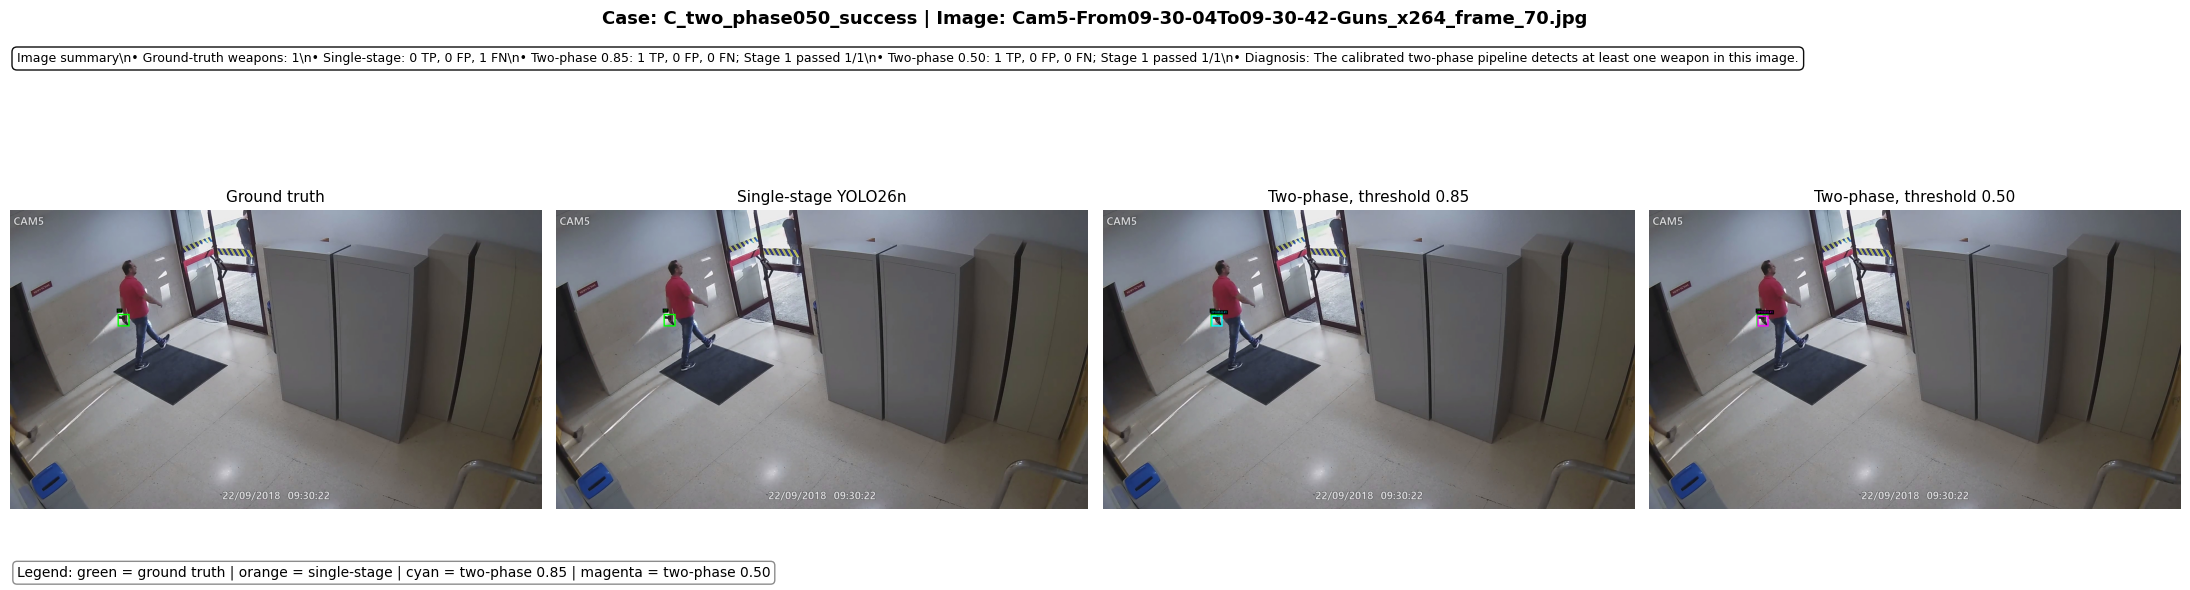

Saved: docs\sprint4_figures\C_two_phase050_success_3_threshold_comparison.png


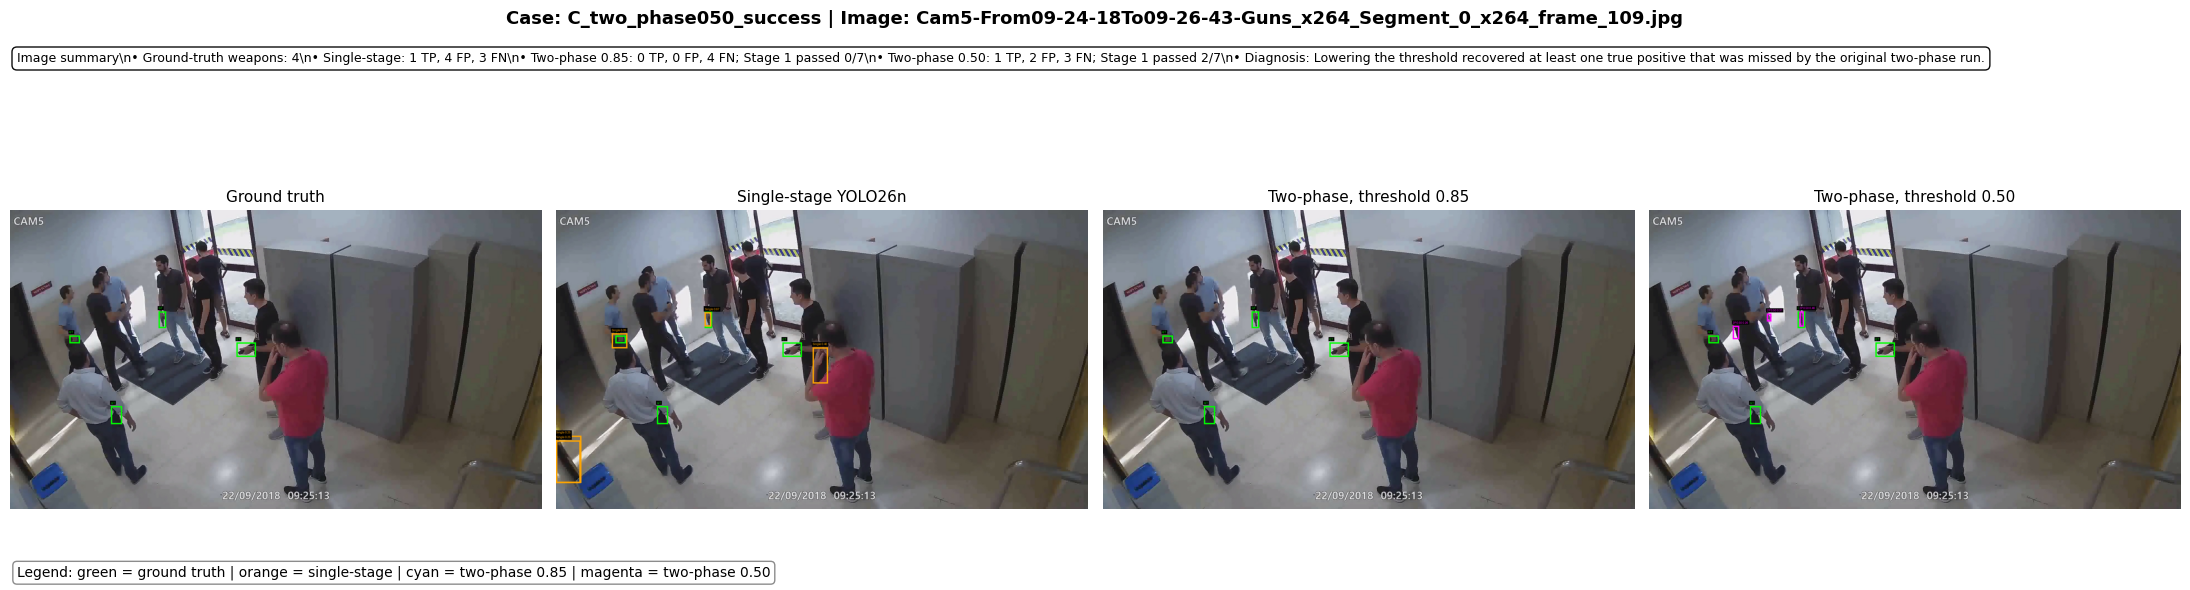

In [12]:
show_case_examples_4panel("C_two_phase050_success", n=3)

## 8. Final interpretation

This cell generates a final Markdown summary for the Sprint 4 report.

In [13]:
single = comparison_085[comparison_085["pipeline"] == "single_stage"].iloc[0]
two_085 = comparison_085[comparison_085["pipeline"] == "two_phase"].iloc[0]
two_050 = comparison_050[comparison_050["pipeline"] == "two_phase"].iloc[0]
pipe_085 = pipeline_085.iloc[0]
pipe_050 = pipeline_050.iloc[0]

final_text = f'''
# Sprint 4 Final Interpretation — Threshold Calibration and Hold-Gate Redesign

The Sprint 4 objective was to implement and evaluate a two-phase detection formulation for CCTV gun detection. The implemented pipeline detects people, classifies each detected person crop as `hold` or `no_hold`, and runs the YOLO26n weapon detector only on crops classified as `hold`.

The first two-phase run used the classifier threshold selected during training: `0.85`. This configuration was too conservative. It detected `{int(pipe_085["persons_detected"])}` people but filtered out `{int(pipe_085["persons_filtered_out"])}` of them, sending only `{int(pipe_085["persons_passed_stage2"])}` candidates to Stage 2. As a result, the two-phase pipeline achieved recall `{two_085["recall"]:.4f}` and F1 `{two_085["f1"]:.4f}`.

To test whether Stage 1 was the main bottleneck, we ran an additional experiment lowering the hold/no_hold threshold from `0.85` to `0.50`. This reduced the number of filtered candidates from `{int(pipe_085["persons_filtered_out"])}` to `{int(pipe_050["persons_filtered_out"])}` and increased the number of candidates passed to Stage 2 from `{int(pipe_085["persons_passed_stage2"])}` to `{int(pipe_050["persons_passed_stage2"])}`. Final weapon detections also increased from `{int(pipe_085["final_weapon_detections"])}` to `{int(pipe_050["final_weapon_detections"])}`.

Quantitatively, the threshold change improved the two-phase pipeline: true positives increased from `{int(two_085["tp"])}` to `{int(two_050["tp"])}`, recall increased from `{two_085["recall"]:.4f}` to `{two_050["recall"]:.4f}`, and F1 increased from `{two_085["f1"]:.4f}` to `{two_050["f1"]:.4f}`. This confirms that the original threshold was one of the main causes of the recall collapse.

However, the calibrated two-phase model still does not outperform the single-stage YOLO26n baseline. The single-stage model achieved precision `{single["precision"]:.4f}`, recall `{single["recall"]:.4f}`, and F1 `{single["f1"]:.4f}`, while the threshold-calibrated two-phase model achieved precision `{two_050["precision"]:.4f}`, recall `{two_050["recall"]:.4f}`, and F1 `{two_050["f1"]:.4f}`.

Therefore, the final recommendation remains to use the single-stage YOLO26n as the current main model. The two-phase pipeline is useful as a Sprint 4 ablation experiment: lowering the threshold improves the pipeline, but the staged architecture still propagates errors from Stage 1 and remains weaker than the baseline for this dataset. After the redesigned permissive hold gate is rerun, this notebook should compare the single-stage baseline, the older F1-selected gate, and the redesigned hold gate.
'''

display(Markdown(final_text))


# Sprint 4 Final Interpretation — Threshold Calibration

The Sprint 4 objective was to implement and evaluate a two-phase detection formulation for CCTV gun detection. The implemented pipeline detects people, classifies each detected person crop as `carry` or `no_carry`, and runs the YOLO26n weapon detector only on crops classified as `carry`.

The first two-phase run used the classifier threshold selected during training: `0.85`. This configuration was too conservative. It detected `2785` people but filtered out `2590` of them, sending only `195` candidates to Stage 2. As a result, the two-phase pipeline achieved recall `0.0040` and F1 `0.0074`.

To test whether Stage 1 was the main bottleneck, we ran an additional experiment lowering the carry/no_carry threshold from `0.85` to `0.50`. This reduced the number of filtered candidates from `2590` to `2051` and increased the number of candidates passed to Stage 2 from `195` to `734`. Final weapon detections also increased from `118` to `357`.

Quantitatively, the threshold change improved the two-phase pipeline: true positives increased from `6` to `24`, recall increased from `0.0040` to `0.0159`, and F1 increased from `0.0074` to `0.0257`. This confirms that the original threshold was one of the main causes of the recall collapse.

However, the calibrated two-phase model still does not outperform the single-stage YOLO26n baseline. The single-stage model achieved precision `0.4325`, recall `0.1758`, and F1 `0.2500`, while the threshold-calibrated two-phase model achieved precision `0.0672`, recall `0.0159`, and F1 `0.0257`.

Therefore, the final recommendation remains to use the single-stage YOLO26n as the current main model. The two-phase pipeline is useful as a Sprint 4 ablation experiment: lowering the threshold improves the pipeline, but the staged architecture still propagates errors from Stage 1 and remains weaker than the baseline for this dataset.




> Threshold calibration confirmed that Stage 1 was the two-phase bottleneck. Lowering the hold threshold improved recall and F1, but the two-phase pipeline still remained below the single-stage YOLO26n baseline. The redesigned permissive hold gate is the next rerun to compare against both earlier scenarios.